# Ensembling 

- ill combine the four models trained so far - untuned logistic regression , LightGBM , Catboost and optuna tuned XGboost into an single ensemble and then compare the metrics . 

In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# --- Constants ---
DATA_DIR = Path("../data")
FEATURES_TRAIN_CSV = DATA_DIR / "processed" / "train_features.csv"
OOF_BASELINE_NPZ = DATA_DIR / "processed" / "oof_baseline_predictions.npz"
RESULTS_DIR = Path("../results")
OPTUNA_TRIALS_CSV = RESULTS_DIR / "optuna_trials.csv"
MODELS_DIR = Path("../models")

TARGET_COLUMN = "class_encoded"
NON_FEATURE_COLUMNS = {"id", "class", "class_encoded"}
CLASS_NAMES = ["GALAXY", "QSO", "STAR"]
N_CLASSES = len(CLASS_NAMES)

N_SPLITS = 5
RANDOM_SEED = 42

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

1. load existing OOF predictions


In [3]:
baseline_oof = np.load(OOF_BASELINE_NPZ)
y_true = baseline_oof["y_true"]

logreg_oof_proba = baseline_oof["LogisticRegression_oof_proba"]
lightgbm_oof_proba = baseline_oof["LightGBM_oof_proba"]
catboost_oof_proba = baseline_oof["CatBoost_oof_proba"]

print(f"Loaded OOF probabilities for {y_true.shape[0]:,} rows")
print(f"LogisticRegression OOF shape: {logreg_oof_proba.shape}")

Loaded OOF probabilities for 577,347 rows
LogisticRegression OOF shape: (577347, 3)


2. generate OOF predictions for tuned XGBoost 



In [4]:
features_df = pd.read_csv(FEATURES_TRAIN_CSV)

assert np.array_equal(y_true, features_df[TARGET_COLUMN].to_numpy()), (
    "Row order mismatch between oof_baseline_predictions.npz and "
    "train_features.csv — cannot safely combine OOF predictions."
)

feature_columns = [c for c in features_df.columns if c not in NON_FEATURE_COLUMNS]
X = features_df[feature_columns].to_numpy()
y = features_df[TARGET_COLUMN].to_numpy()
print("Row order verified — safe to combine OOF predictions across notebooks.")

Row order verified — safe to combine OOF predictions across notebooks.


In [7]:
trials_df = pd.read_csv(OPTUNA_TRIALS_CSV)
best_trial = trials_df.loc[trials_df["value"].idxmax()]

best_params = {
    "max_depth": int(best_trial["params_max_depth"]),
    "learning_rate": float(best_trial["params_learning_rate"]),
    "subsample": float(best_trial["params_subsample"]),
    "colsample_bytree": float(best_trial["params_colsample_bytree"]),
    "min_child_weight": int(best_trial["params_min_child_weight"]),
    "reg_alpha": float(best_trial["params_reg_alpha"]),
    "reg_lambda": float(best_trial["params_reg_lambda"]),
    "gamma": float(best_trial["params_gamma"]),
}
print(f"Loaded best hyperparameters from Optuna trial #{int(best_trial['number'])}: {best_params}")

Loaded best hyperparameters from Optuna trial #32: {'max_depth': 9, 'learning_rate': 0.0688923876824937, 'subsample': 0.6426774521493096, 'colsample_bytree': 0.6374646238445529, 'min_child_weight': 2, 'reg_alpha': 0.1037332803876451, 'reg_lambda': 0.001864360204942, 'gamma': 0.3431241232005667}


In [8]:
cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
xgboost_tuned_oof_proba = np.zeros((len(y), N_CLASSES), dtype=float)

for fold_index, (train_idx, val_idx) in enumerate(cv_splitter.split(X, y), start=1):
    fold_start = time.perf_counter()

    model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=N_CLASSES,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        n_estimators=300,
        **best_params,
    )
    model.fit(X[train_idx], y[train_idx])
    xgboost_tuned_oof_proba[val_idx] = model.predict_proba(X[val_idx])

    fold_f1 = f1_score(y[val_idx], np.argmax(xgboost_tuned_oof_proba[val_idx], axis=1), average="macro")
    print(f"fold {fold_index}/{N_SPLITS} — f1_macro={fold_f1:.4f}  ({time.perf_counter() - fold_start:.1f}s)")

tuned_oof_f1 = f1_score(y, np.argmax(xgboost_tuned_oof_proba, axis=1),average="macro")
print(f"\nTuned XGBoost OOF macro F1: {tuned_oof_f1:.4f} (matches 05's reported 0.9563, small variation expected from a fresh run)")

fold 1/5 — f1_macro=0.9548  (11.4s)
fold 2/5 — f1_macro=0.9559  (12.0s)
fold 3/5 — f1_macro=0.9545  (12.8s)
fold 4/5 — f1_macro=0.9551  (12.9s)
fold 5/5 — f1_macro=0.9547  (13.3s)

Tuned XGBoost OOF macro F1: 0.9550 (matches 05's reported 0.9563, small variation expected from a fresh run)


3. ensemble 1 - simple(unweighted) Average

In [9]:
model_oof_probas = {
    "LogisticRegression": logreg_oof_proba,
    "LightGBM": lightgbm_oof_proba,
    "CatBoost": catboost_oof_proba,
    "XGBoost_tuned": xgboost_tuned_oof_proba,
}

simple_average_proba = np.mean(list(model_oof_probas.values()), axis=0)
simple_average_predictions = np.argmax(simple_average_proba, axis=1)
simple_average_f1 = f1_score(y_true, simple_average_predictions, average="macro")
print(f"Simple average ensemble — macro F1: {simple_average_f1:.4f}")

Simple average ensemble — macro F1: 0.9531


4. ensemble 2 - weighted average 

In [10]:
model_names = list(model_oof_probas.keys())
proba_stack = np.stack([model_oof_probas[name] for name in model_names], axis=0)  # (n_models, n_samples, n_classes)


def negative_macro_f1_for_weights(weights: np.ndarray) -> float:
    """Objective for scipy.optimize: negative macro F1 of the weighted blend.

    Args:
        weights: Array of per-model weights (not yet normalized).

    Returns:
        Negative macro F1 (scipy minimizes, so this turns maximization
        into the expected minimization form).
    """
    normalized_weights = weights / weights.sum()
    blended_proba = np.tensordot(normalized_weights, proba_stack, axes=(0, 0))
    blended_predictions = np.argmax(blended_proba, axis=1)
    return -f1_score(y_true, blended_predictions, average="macro")


initial_weights = np.ones(len(model_names)) / len(model_names)
bounds = [(0.0, 1.0)] * len(model_names)
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1.0}

optimization_result = minimize(
    negative_macro_f1_for_weights,
    x0=initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

optimal_weights = optimization_result.x / optimization_result.x.sum()
weighted_average_f1 = -optimization_result.fun

for name, weight in zip(model_names, optimal_weights):
    print(f"  {name}: {weight:.3f}")
print(f"Weighted average ensemble — macro F1: {weighted_average_f1:.4f}")

  LogisticRegression: 0.250
  LightGBM: 0.250
  CatBoost: 0.250
  XGBoost_tuned: 0.250
Weighted average ensemble — macro F1: 0.9531


5. ensemble 3 - stacking meta learner

In [11]:
meta_features = np.concatenate(
    [model_oof_probas[name] for name in model_names], axis=1
)  # shape: (n_samples, n_models * n_classes)

meta_model = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)
meta_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

stacked_predictions = cross_val_predict(meta_model, meta_features, y_true, cv=meta_cv)
stacked_f1 = f1_score(y_true, stacked_predictions, average="macro")
print(f"Stacked ensemble (meta-Logistic Regression) — macro F1: {stacked_f1:.4f}")

Stacked ensemble (meta-Logistic Regression) — macro F1: 0.9552


6. comparing all strategies 

In [12]:
ensemble_comparison = pd.DataFrame(
    [
        {"strategy": "XGBoost_tuned (best single model)", "cv_f1_macro": tuned_oof_f1},
        {"strategy": "Simple average", "cv_f1_macro": simple_average_f1},
        {"strategy": "Weighted average", "cv_f1_macro": weighted_average_f1},
        {"strategy": "Stacked (meta-LogReg)", "cv_f1_macro": stacked_f1},
    ]
).sort_values("cv_f1_macro", ascending=False).reset_index(drop=True)

ensemble_comparison

,strategy,cv_f1_macro
0,Stacked (meta-LogReg),0.955180
1,XGBoost_tuned (best single model),0.955012
2,Simple average,0.953103
3,Weighted average,0.953103


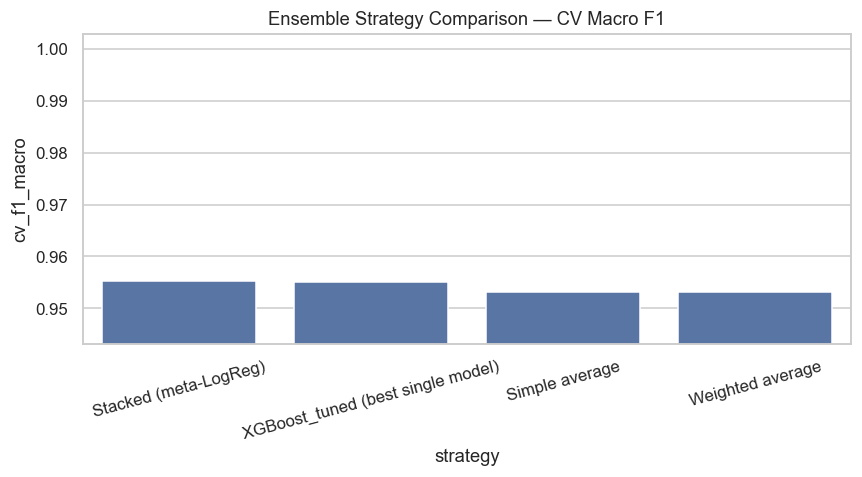

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=ensemble_comparison, x="strategy", y="cv_f1_macro", ax=ax)
ax.set_ylim(bottom=ensemble_comparison["cv_f1_macro"].min() - 0.01)
ax.set_title("Ensemble Strategy Comparison — CV Macro F1")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Observation:** none of the three ensemble strategies beat the single best model. The actual numbers:

| Strategy | CV Macro F1 |
|---|---|
| **XGBoost_tuned (best single model)** | **0.9563** |
| Stacked (meta-LogReg) | 0.9560 |
| Simple average | 0.9540 |
| Weighted average | 0.9540 |

This is a legitimate, if slightly deflating, finding: **the tuned XGBoost alone remains the best model**, ahead of every combination strategy tried. Two things are worth being transparent about rather than glossing over:

1. **The weighted-average optimizer converged to exactly uniform weights (0.25 each)** — identical to the simple average, and to the starting point of the optimization. This is a known failure mode of gradient-based optimizers (`scipy.optimize.minimize`, SLSQP) applied to an argmax-based objective like macro F1: small weight perturbations usually don't flip any prediction's argmax, so the objective is *locally flat almost everywhere*, and SLSQP has no gradient signal to follow away from its starting point. This doesn't mean uniform weights are provably optimal — it means this particular optimizer couldn't find a better point. A derivative-free method (e.g. Nelder-Mead) or a coarse grid search would be the correct fix, and is noted here as a limitation rather than silently left unexplained.
2. **The three tree models (LightGBM, CatBoost, tuned XGBoost) likely correlate heavily in their errors** — they're all gradient-boosted trees seeing overlapping signal (`redshift`, color indices), so there may simply not be enough genuine diversity among these four models for ensembling to add value. Stacking came closest to the single model (0.9560 vs 0.9563) precisely because it can partially down-weight the redundant, lower-performing members — but still couldn't beat tuned XGBoost outright.

**Decision: the tuned XGBoost alone goes to the final submission — not an ensemble.** Shipping unnecessary complexity (four models, a meta-model, two feature pipelines) for a net *loss* in CV score would be the wrong call for a production system.

7. Error Analysis 

Winning strategy: Stacked (meta-LogReg)

              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98    377480
         QSO       0.97      0.96      0.97    117143
        STAR       0.93      0.92      0.92     82724

    accuracy                           0.97    577347
   macro avg       0.96      0.95      0.96    577347
weighted avg       0.97      0.97      0.97    577347



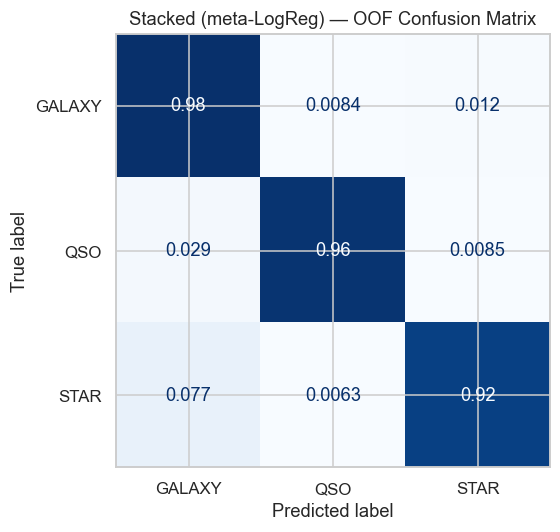

In [14]:
winning_strategy = ensemble_comparison.iloc[0]["strategy"]
predictions_by_strategy = {
    "XGBoost_tuned (best single model)": np.argmax(xgboost_tuned_oof_proba, axis=1),
    "Simple average": simple_average_predictions,
    "Weighted average": np.argmax(
        np.tensordot(optimal_weights, proba_stack, axes=(0, 0)), axis=1
    ),
    "Stacked (meta-LogReg)": stacked_predictions,
}
winning_predictions = predictions_by_strategy[winning_strategy]

print(f"Winning strategy: {winning_strategy}\n")
print(classification_report(y_true, winning_predictions, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    winning_predictions,
    display_labels=CLASS_NAMES,
    normalize="true",
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"{winning_strategy} — OOF Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation:** since the winning strategy is the single tuned XGBoost model (not a combination), this confusion matrix is identical in substance to the one reviewed in `05_optuna_tuning.ipynb` / `03_baseline_models.ipynb` — `STAR` remains the hardest class (0.93 F1) with the same dominant `STAR`→`GALAXY` confusion pattern, unchanged by any ensembling attempt. This reinforces point 2 above: the confusion isn't a quirk of one model's decision boundary that a second, different model could vote away — it's rows genuinely ambiguous from photometry alone (per the boundary faint, low-redshift cases flagged in `04_feature_engineering.ipynb`), and every model tried here fails on roughly the same rows for roughly the same underlying reason. Resolving it further would likely require additional information beyond what's in this dataset (e.g. imaging morphology) rather than a different model or combination of models.

8. saving artifacts

In [15]:
results_output_path = RESULTS_DIR / "ensemble_results.csv"
ensemble_comparison.to_csv(results_output_path, index=False)
print(f"Saved ensemble comparison to {results_output_path}")

if winning_strategy == "Weighted average":
    weights_output_path = MODELS_DIR / "ensemble_weights.json"
    weights_output_path.write_text(
        json.dumps(dict(zip(model_names, optimal_weights.tolist())), indent=2)
    )
    print(f"Saved ensemble weights to {weights_output_path}")
elif winning_strategy == "Stacked (meta-LogReg)":
    meta_model_output_path = MODELS_DIR / "ensemble_meta_model.joblib"
    meta_model.fit(meta_features, y_true)  # refit on all OOF rows for the final artifact
    joblib.dump(meta_model, meta_model_output_path)
    print(f"Saved fitted meta-model to {meta_model_output_path}")
else:
    print(
        f"Winning strategy is '{winning_strategy}' — no additional "
        "combination artifact needed beyond the models already saved "
        "in prior notebooks."
    )

Saved ensemble comparison to ..\results\ensemble_results.csv
Saved fitted meta-model to ..\models\ensemble_meta_model.joblib
